# Redes generativas adversarias (GAN)

> Cómo dos redes que compiten, un generador que fabrica imágenes a partir de ruido y un discriminador que intenta distinguirlas de las reales, acaban aprendiendo a generar datos nuevos. El juego minimax, la pérdida no saturante, una GAN densa y una convolucional (DCGAN) sobre MNIST, cómo medir la calidad y la diversidad de lo generado y los errores típicos: una sigmoide de más, un `detach` mal colocado o leer las pérdidas como si midieran la calidad.
>
> **Requisitos previos:** [Redes neuronales densas](01-redes-neuronales-densas.ipynb) · [Redes convolucionales](03-redes-convolucionales.ipynb) · **Relacionado:** [Autoencoders](05-autoencoders.ipynb) · [Modelos de difusión](09-modelos-de-difusion.ipynb)

## 1. Idea clave

Un **modelo generativo** aprende la distribución de los datos para poder **muestrear ejemplos nuevos** que se parezcan a los reales. Una **GAN** (*generative adversarial network*) lo consigue con un juego entre dos redes: el **generador** transforma ruido aleatorio en una muestra y el **discriminador** recibe muestras reales y generadas e intenta distinguirlas. Se entrenan por turnos: el discriminador aprende a detectar las falsificaciones y el generador aprende a engañarlo. Si el juego llega al equilibrio, las muestras generadas son indistinguibles de las reales.

Las GAN generan imágenes **nítidas** y **muy rápido** (una sola pasada por la red), pero su entrenamiento es **inestable**, pueden quedarse generando solo unos pocos tipos de muestra (**colapso de modos**) y son difíciles de evaluar, porque no dan una probabilidad de los datos. En calidad y estabilidad las han superado los [modelos de difusión](09-modelos-de-difusion.ipynb); siguen usándose cuando la velocidad de generación importa.

## 2. Conceptos importantes

### 2.1. Generar a partir de ruido

El generador $G$ es una red que recibe un vector **latente** $\mathbf{z}\in\mathbb{R}^{k}$ muestreado de una distribución sencilla, normalmente $\mathbf{z}\sim\mathcal{N}(\mathbf{0},\mathbf{I})$, y devuelve una muestra $G(\mathbf{z})$ con la forma de los datos (una imagen). Cada $\mathbf{z}$ distinto da una muestra distinta; la red aprende a "deformar" la normal hasta que se parezca a la distribución de los datos $p_\text{datos}$. La distribución resultante, $p_g$, nunca se escribe explícitamente: solo se puede muestrear (modelo **implícito**).

El discriminador $D$ recibe una muestra $\mathbf{x}$ y devuelve $D(\mathbf{x})\in(0,1)$, la probabilidad de que sea real. Es un clasificador binario.

### 2.2. El juego minimax

$D$ quiere acertar y $G$ quiere que $D$ falle:

$$
\min_G\max_D\;V(D,G)=\mathbb{E}_{\mathbf{x}\sim p_\text{datos}}\left[\log D(\mathbf{x})\right]+\mathbb{E}_{\mathbf{z}\sim\mathcal{N}(\mathbf{0},\mathbf{I})}\left[\log\left(1-D(G(\mathbf{z}))\right)\right].
$$

Para un $G$ fijo, el discriminador óptimo es $D^*(\mathbf{x})=\dfrac{p_\text{datos}(\mathbf{x})}{p_\text{datos}(\mathbf{x})+p_g(\mathbf{x})}$, y con él el generador minimiza la divergencia de Jensen-Shannon entre $p_\text{datos}$ y $p_g$. El óptimo global es $p_g=p_\text{datos}$, donde $D^*=1/2$ en todas partes: el discriminador ya no puede hacer nada mejor que tirar una moneda.

### 2.3. Cómo se entrena en la práctica

En cada lote se alternan dos pasos, cada uno con su optimizador:

1. **Paso de $D$**: entropía cruzada binaria (BCE) con etiqueta 1 para las imágenes reales y 0 para las generadas. Las generadas se pasan con `.detach()` para que este paso no calcule gradientes del generador.
2. **Paso de $G$**: se generan imágenes, se pasan por $D$ **sin** `detach` y se calcula la BCE con etiqueta **1** ("hazlas pasar por reales"). El gradiente atraviesa $D$ (que no se actualiza en este paso) y llega a $G$.

El paso 2 minimiza $-\log D(G(\mathbf{z}))$ en lugar de $\log(1-D(G(\mathbf{z})))$: es la pérdida **no saturante**. Al principio $D$ rechaza las falsificaciones con facilidad ($D(G(\mathbf{z}))\approx 0$), y ahí $\log(1-D)$ es casi plana (gradiente casi nulo) mientras que $-\log D$ es muy empinada, así que el generador aprende desde el primer momento. En PyTorch, $D$ devuelve el **logit** (sin sigmoide) y se usa `BCEWithLogitsLoss`, que aplica la sigmoide internamente de forma numéricamente estable.

### 2.4. Problemas típicos

- **Colapso de modos** (*mode collapse*): el generador encuentra unas pocas muestras que engañan a $D$ y produce solo esas (por ejemplo, solo unos dígitos). Las muestras son buenas pero poco diversas.
- **No convergencia**: las dos redes oscilan sin estabilizarse. Las pérdidas de una GAN **no bajan de forma monótona** ni miden la calidad: son la puntuación de un juego contra un rival que también cambia.
- **Desvanecimiento del gradiente**: si $D$ gana con mucha ventaja, el generador apenas recibe señal.

### 2.5. Cómo evaluar lo generado

No hay una pérdida que diga si las muestras son buenas. Se combinan:

- **Inspección visual**, con un $\mathbf{z}$ fijo a lo largo del entrenamiento.
- **Distancia de Fréchet**: se extraen características de imágenes reales y generadas con una red preentrenada, se ajusta una normal a cada grupo y se mide la distancia entre ellas:

$$
d_F^2=\lVert\boldsymbol{\mu}_r-\boldsymbol{\mu}_g\rVert^2+\operatorname{Tr}\left(\boldsymbol{\Sigma}_r+\boldsymbol{\Sigma}_g-2\left(\boldsymbol{\Sigma}_r\boldsymbol{\Sigma}_g\right)^{1/2}\right),
$$

  donde $\boldsymbol{\mu}$ y $\boldsymbol{\Sigma}$ son la media y la covarianza de las características (r = reales, g = generadas). Menor es mejor, y penaliza tanto la mala calidad como la falta de diversidad. El **FID** estándar usa la red Inception-v3; aquí usaremos un clasificador propio de dígitos (3.2), así que los valores solo son comparables entre sí.
- **Diversidad**: con un clasificador, el reparto de clases de las muestras generadas (en MNIST debería ser ≈ 10 % por dígito).

### 2.6. Variantes

- **DCGAN**: generador con convoluciones transpuestas y discriminador convolucional, normalización por lotes y LeakyReLU. Es la base de casi todas las GAN de imágenes (3.4).
- **GAN condicional**: $G$ y $D$ reciben también la etiqueta, para generar "un 7" a voluntad.
- **WGAN / WGAN-GP**: cambian la BCE por una estimación de la distancia de Wasserstein; entrenamiento más estable.
- **StyleGAN, CycleGAN, Pix2Pix**: generación de caras de alta resolución, traducción entre dominios de imagen (caballo ↔ cebra, boceto → foto).

## 3. Código

Usamos **MNIST** (60 000 dígitos manuscritos de $28\times28$ para entrenamiento y 10 000 de test). Los píxeles se llevan al rango $[-1,1]$, el mismo que la salida `tanh` del generador. Las etiquetas no se usan para entrenar las GAN, solo para el clasificador "juez" de 3.2.

In [1]:
import contextlib
import copy
import io
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.linalg import sqrtm
from torchvision import datasets

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.backends.cudnn.deterministic = True                 # resultados reproducibles en GPU (algo más lento)
torch.backends.cudnn.benchmark = False

### 3.1. Datos

entrenamiento (60000, 1, 28, 28), test (10000, 1, 28, 28), rango [-1, 1]


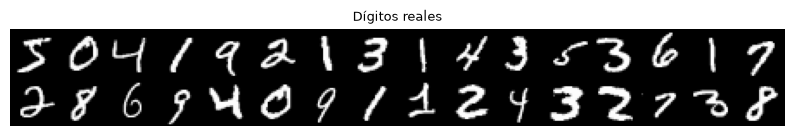

In [2]:
with contextlib.redirect_stderr(io.StringIO()):          # silencia las barras de descarga
    entrenamiento = datasets.MNIST("data", train=True, download=True)
    prueba = datasets.MNIST("data", train=False, download=True)

X = (entrenamiento.data.float() / 127.5 - 1).unsqueeze(1).to(device)     # (60000, 1, 28, 28) en [-1, 1]
y = entrenamiento.targets.to(device)
X_test = (prueba.data.float() / 127.5 - 1).unsqueeze(1).to(device)
y_test = prueba.targets.to(device)
print(f"entrenamiento {tuple(X.shape)}, test {tuple(X_test.shape)}, rango [{X.min():.0f}, {X.max():.0f}]")

def mostrar(imagenes, titulo, filas=2, ax=None):
    """Dibuja una rejilla con las imágenes (N, 1, 28, 28) en [-1, 1]."""
    imgs = imagenes[: filas * 16].detach().cpu().squeeze(1).add(1).div(2).clamp(0, 1)
    rejilla = imgs.view(filas, 16, 28, 28).permute(0, 2, 1, 3).reshape(filas * 28, 16 * 28)
    ax = ax or plt.subplots(figsize=(10, 0.65 * filas + 0.4))[1]
    ax.imshow(rejilla, cmap="gray"); ax.set_title(titulo, fontsize=9); ax.axis("off")

mostrar(X[:32], "Dígitos reales")
plt.show()

### 3.2. Un juez para medir calidad y diversidad

Entrenamos un clasificador convolucional pequeño con las imágenes reales. Lo usaremos de dos formas: para saber qué dígito "ve" en cada muestra generada (diversidad) y, con las 128 características de su penúltima capa, para calcular la **distancia de Fréchet** entre muestras reales y generadas (calidad, 2.5). Como referencia, la distancia entre dos conjuntos de imágenes **reales** (entrenamiento y test) es el mejor valor alcanzable.

In [3]:
class Juez(nn.Module):
    def __init__(self):
        super().__init__()
        self.caracteristicas = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(64 * 7 * 7, 128), nn.ReLU())
        self.clasificador = nn.Linear(128, 10)

    def forward(self, x):
        return self.clasificador(self.caracteristicas(x))

torch.manual_seed(0)
juez = Juez().to(device)
opt = torch.optim.Adam(juez.parameters(), lr=1e-3)
for epoca in range(2):
    juez.train()
    for i in torch.randperm(len(X), device=device).split(128):
        opt.zero_grad()
        F.cross_entropy(juez(X[i]), y[i]).backward()
        opt.step()
juez.eval()

@torch.no_grad()
def analizar(imagenes):
    """Características de la penúltima capa y probabilidades de cada dígito."""
    c = torch.cat([juez.caracteristicas(b) for b in imagenes.split(2000)])
    return c.cpu().double().numpy(), juez.clasificador(c).softmax(-1).cpu()

def distancia_frechet(c_a, c_b):
    mu_a, mu_b = c_a.mean(0), c_b.mean(0)
    eps = 1e-6 * np.eye(c_a.shape[1])                     # algunas neuronas ReLU nunca se activan: covarianza singular
    s_a, s_b = np.cov(c_a, rowvar=False) + eps, np.cov(c_b, rowvar=False) + eps
    raiz = sqrtm(s_a @ s_b).real
    return float(((mu_a - mu_b) ** 2).sum() + np.trace(s_a + s_b - 2 * raiz))

caract_test, prob_test = analizar(X_test)
print(f"Acierto del juez en test: {(prob_test.argmax(1) == y_test.cpu()).float().mean():.3f}")
print(f"Distancia de Fréchet entre 10 000 imágenes reales de entrenamiento y las de test: {distancia_frechet(analizar(X[:10000])[0], caract_test):.2f}")

Acierto del juez en test: 0.984
Distancia de Fréchet entre 10 000 imágenes reales de entrenamiento y las de test: 2.90


El juez acierta el 98,4 % de los dígitos de test. La distancia de Fréchet entre dos conjuntos de imágenes reales es 2,90: ese es el suelo con el que comparar (no llega a 0 porque dos muestras distintas de la misma distribución no son idénticas). Los valores dependen de la red que extrae las características y del número de imágenes, así que solo sirven para comparar dentro de este notebook.

### 3.3. GAN densa

Generador: $\mathbf{z}\in\mathbb{R}^{64}$ → 256 → 512 → 1024 → 784 con LeakyReLU y `tanh` a la salida. Discriminador: 784 → 512 → 256 → 1 con LeakyReLU y *dropout*, **sin sigmoide** (devuelve el logit). Adam con $\text{lr}=2\cdot10^{-4}$ y $\beta_1=0{,}5$ (lo habitual en GAN), lotes de 128 y 30 épocas. En cada época guardamos las pérdidas, la salida media de $D$ (como probabilidad) para imágenes reales y generadas y la distancia de Fréchet de 5 000 muestras.

In [4]:
LATENTE = 64

def generador_denso():
    return nn.Sequential(
        nn.Linear(LATENTE, 256), nn.LeakyReLU(0.2),
        nn.Linear(256, 512), nn.LeakyReLU(0.2),
        nn.Linear(512, 1024), nn.LeakyReLU(0.2),
        nn.Linear(1024, 784), nn.Tanh(), nn.Unflatten(1, (1, 28, 28)))

def discriminador_denso():
    return nn.Sequential(
        nn.Flatten(),
        nn.Linear(784, 512), nn.LeakyReLU(0.2), nn.Dropout(0.3),
        nn.Linear(512, 256), nn.LeakyReLU(0.2), nn.Dropout(0.3),
        nn.Linear(256, 1))                                # logit: sin sigmoide

@torch.no_grad()
def generar(G, n, semilla=123):
    G.eval()
    z = torch.randn(n, LATENTE, generator=torch.Generator(device=device).manual_seed(semilla), device=device)
    muestras = G(z)
    G.train()
    return muestras

def entrenar_gan(G, D, epocas, instantaneas=(), lr=2e-4, semilla=0):
    torch.manual_seed(semilla)
    G, D = G.to(device), D.to(device)
    opt_G = torch.optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_D = torch.optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))
    bce = nn.BCEWithLogitsLoss()
    historia, fotos = [], {}
    for epoca in range(1, epocas + 1):
        suma = np.zeros(4)
        lotes = torch.randperm(len(X), device=device).split(128)
        for i in lotes:
            reales = X[i]
            unos, ceros = torch.ones(len(i), 1, device=device), torch.zeros(len(i), 1, device=device)
            falsas = G(torch.randn(len(i), LATENTE, device=device))

            # Paso de D: reales -> 1, generadas -> 0 (detach: no calcular gradientes de G)
            d_reales, d_falsas = D(reales), D(falsas.detach())
            perdida_D = bce(d_reales, unos) + bce(d_falsas, ceros)
            opt_D.zero_grad(); perdida_D.backward(); opt_D.step()

            # Paso de G: que D tome las generadas por reales (pérdida no saturante)
            perdida_G = bce(D(falsas), unos)
            opt_G.zero_grad(); perdida_G.backward(); opt_G.step()

            suma += [perdida_D.item(), perdida_G.item(), d_reales.sigmoid().mean().item(), d_falsas.sigmoid().mean().item()]
        historia.append({"época": epoca, **dict(zip(["pérdida D", "pérdida G", "D(real)", "D(generada)"], suma / len(lotes))),
                         "Fréchet": distancia_frechet(analizar(generar(G, 5000))[0], caract_test[:5000])})
        if epoca in instantaneas:
            fotos[epoca] = generar(G, 32)
    return G, pd.DataFrame(historia).set_index("época"), fotos

inicio = time.time()
G_denso, hist_denso, fotos_denso = entrenar_gan(generador_denso(), discriminador_denso(), 30, instantaneas=(1, 5, 30))
print(f"Entrenada en {time.time() - inicio:.0f} s; generador con {sum(p.numel() for p in G_denso.parameters()):,} parámetros")
hist_denso.iloc[[0, 4, 9, 19, 29]].round(3)

Entrenada en 45 s; generador con 1,477,136 parámetros


,pérdida D,pérdida G,D(real),D(generada),Fréchet
época,,,,,
1,1.126,1.066,0.684,0.499,1134.312
5,0.826,2.031,0.731,0.282,429.798
10,0.989,1.443,0.670,0.335,188.018
20,1.228,0.981,0.573,0.430,77.104
30,1.276,0.918,0.553,0.447,56.918


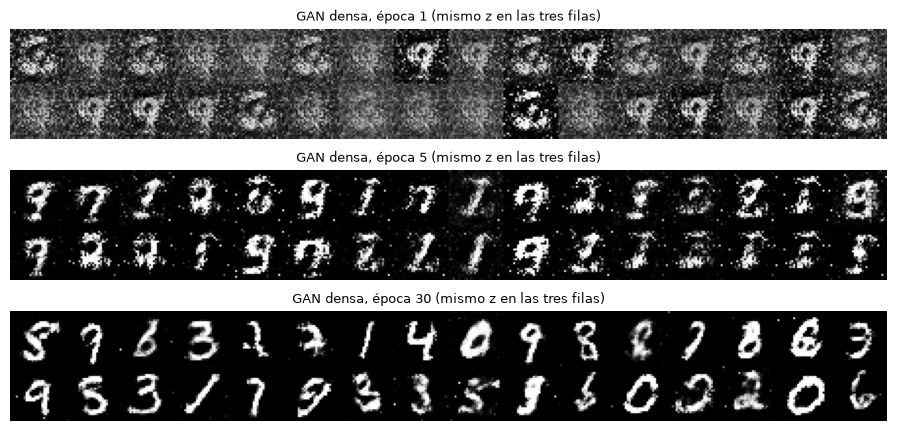

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(10, 4.4))
for ax, (epoca, muestras) in zip(axes, fotos_denso.items()):
    mostrar(muestras, f"GAN densa, época {epoca} (mismo z en las tres filas)", filas=2, ax=ax)
plt.tight_layout()
plt.show()

En la época 1 el generador produce manchas muy parecidas para casi todos los $\mathbf{z}$; en la 5 ya aparecen trazos con forma de dígito, pero llenos de ruido; en la 30 la mayoría de las muestras son dígitos reconocibles, aunque con trazos irregulares y algunas formas ambiguas. La distancia de Fréchet lo refleja: 1 134 en la época 1, 430 en la 5, 188 en la 10 y 57 en la 30.

Las pérdidas cuentan otra historia: la de $G$ **sube** de 1,07 a 2,03 entre las épocas 1 y 5 mientras las muestras mejoran mucho, porque $D$ también aprende (su salida media para las generadas baja de 0,50 a 0,28). Después el juego se equilibra: en la época 30, $D$ asigna de media 0,55 a las reales y 0,45 a las generadas, cerca del 0,5 del equilibrio teórico (2.2).

### 3.4. DCGAN: una GAN convolucional

El generador proyecta $\mathbf{z}$ a un tensor de $128\times7\times7$ y lo amplía con dos convoluciones transpuestas de *stride* 2 ($7\to14\to28$), con normalización por lotes y ReLU. El discriminador es el camino inverso: dos convoluciones de *stride* 2 con LeakyReLU y una capa lineal hasta el logit, sin normalización por lotes (4.1). 15 épocas.

Entrenada en 43 s; generador con 540,225 parámetros
Distancia de Fréchet en las épocas 1, 5, 10 y 15: [229.8, 97.8, 69.8, 55.3]


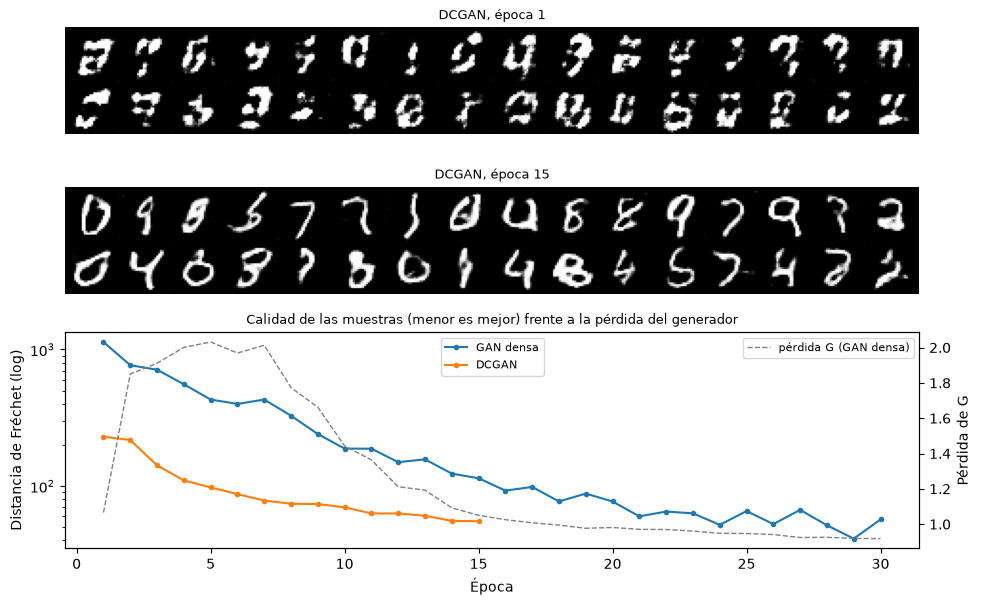

In [6]:
def generador_conv():
    return nn.Sequential(
        nn.Linear(LATENTE, 128 * 7 * 7), nn.Unflatten(1, (128, 7, 7)), nn.BatchNorm2d(128), nn.ReLU(),
        nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1), nn.BatchNorm2d(64), nn.ReLU(),      # 7 -> 14
        nn.ConvTranspose2d(64, 1, 4, stride=2, padding=1), nn.Tanh())                            # 14 -> 28

def discriminador_conv():
    return nn.Sequential(
        nn.Conv2d(1, 64, 4, stride=2, padding=1), nn.LeakyReLU(0.2),                             # 28 -> 14
        nn.Conv2d(64, 128, 4, stride=2, padding=1), nn.LeakyReLU(0.2),                            # 14 -> 7
        nn.Flatten(), nn.Linear(128 * 7 * 7, 1))

inicio = time.time()
G_conv, hist_conv, fotos_conv = entrenar_gan(generador_conv(), discriminador_conv(), 15, instantaneas=(1, 15))
print(f"Entrenada en {time.time() - inicio:.0f} s; generador con {sum(p.numel() for p in G_conv.parameters()):,} parámetros")
print("Distancia de Fréchet en las épocas 1, 5, 10 y 15:", hist_conv["Fréchet"].loc[[1, 5, 10, 15]].round(1).tolist())

fig = plt.figure(figsize=(10, 6.2))
ejes = fig.subplots(3, 1, height_ratios=[1, 1, 1.6])
mostrar(fotos_conv[1], "DCGAN, época 1", filas=2, ax=ejes[0])
mostrar(fotos_conv[15], "DCGAN, época 15", filas=2, ax=ejes[1])
ax = ejes[2]
ax.plot(hist_denso.index, hist_denso["Fréchet"], marker=".", label="GAN densa")
ax.plot(hist_conv.index, hist_conv["Fréchet"], marker=".", label="DCGAN")
ax.set_yscale("log"); ax.set_xlabel("Época"); ax.set_ylabel("Distancia de Fréchet (log)")
ax2 = ax.twinx()
ax2.plot(hist_denso.index, hist_denso["pérdida G"], color="gray", ls="--", lw=1, label="pérdida G (GAN densa)")
ax2.set_ylabel("Pérdida de G")
ax.legend(loc="upper center", fontsize=8); ax2.legend(loc="upper right", fontsize=8)
ax.set_title("Calidad de las muestras (menor es mejor) frente a la pérdida del generador", fontsize=9)
plt.tight_layout()
plt.show()

Con convoluciones, desde la primera época aparecen formas de dígito y la DCGAN mejora mucho más deprisa: en la época 5 su distancia de Fréchet ya es menor que la de la GAN densa en la época 10, y en 15 épocas llega al nivel que la densa solo alcanza al final de sus 30, con un generador de 540 000 parámetros frente a 1,48 millones. Sus trazos son más limpios y continuos (sin los píxeles sueltos de la densa), aunque algunas muestras siguen siendo formas ambiguas.

El gráfico inferior muestra también que la pérdida del generador no sigue a la calidad: en las primeras épocas sube mientras la distancia de Fréchet cae.

### 3.5. Diversidad: ¿genera todos los dígitos?

Generamos 10 000 muestras con cada GAN y el juez decide qué dígito es cada una. Si hubiera colapso de modos, unos pocos dígitos acapararían las muestras. La **confianza media** (probabilidad máxima del juez) indica además si las muestras son dígitos claros o ambiguos.

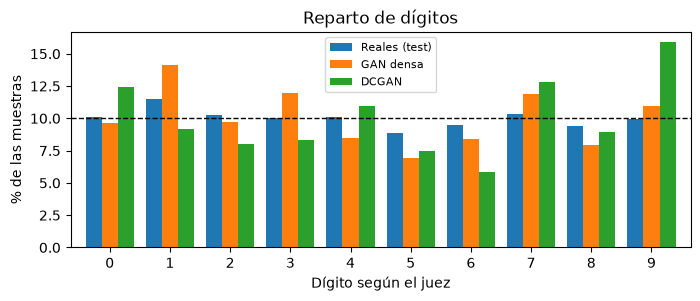

,Fréchet,confianza media,dígito más frecuente (%),dígito menos frecuente (%)
Reales (test),0.00,0.98,11.53,8.85
GAN densa,64.98,0.90,14.13,6.91
DCGAN,60.31,0.86,15.90,5.88


In [7]:
resumen, repartos = {}, {}
for nombre, muestras in [("Reales (test)", X_test), ("GAN densa", generar(G_denso, 10000)), ("DCGAN", generar(G_conv, 10000))]:
    caract, prob = analizar(muestras)
    repartos[nombre] = torch.bincount(prob.argmax(1), minlength=10).numpy() / len(prob)
    resumen[nombre] = {"Fréchet": distancia_frechet(caract, caract_test) if nombre != "Reales (test)" else 0.0,
                       "confianza media": prob.max(1).values.mean().item(),
                       "dígito más frecuente (%)": 100 * repartos[nombre].max(),
                       "dígito menos frecuente (%)": 100 * repartos[nombre].min()}

fig, ax = plt.subplots(figsize=(8, 2.8))
pd.DataFrame(repartos, index=range(10)).mul(100).plot.bar(ax=ax, width=0.8)
ax.axhline(10, color="k", ls="--", lw=1)
ax.set_xlabel("Dígito según el juez"); ax.set_ylabel("% de las muestras"); ax.set_title("Reparto de dígitos")
ax.tick_params(axis="x", rotation=0); ax.legend(fontsize=8)
plt.show()
pd.DataFrame(resumen).T.round(2)

Ninguna GAN muestra colapso de modos: las dos generan los 10 dígitos, con repartos entre el 6,9 % y el 14,1 % (GAN densa) y entre el 5,9 % y el 15,9 % (DCGAN), frente al 8,9–11,5 % de las imágenes reales. Hay sesgos moderados (la DCGAN genera demasiados 9 y pocos 6; la densa, demasiados 1), y la confianza media del juez es menor que con imágenes reales (0,90 y 0,86 frente a 0,98): una parte de las muestras son dígitos ambiguos. Con 10 000 muestras, la DCGAN queda algo mejor en distancia de Fréchet (60 frente a 65), una diferencia pequeña que, con un solo entrenamiento por modelo, no basta para declarar un ganador; su ventaja clara es llegar ahí con la mitad de épocas y un tercio de los parámetros.

### 3.6. Interpolar en el espacio latente

Si el generador ha aprendido un espacio latente "continuo", recorrer en línea recta el camino entre dos vectores $\mathbf{z}_a$ y $\mathbf{z}_b$ debe producir una transformación suave entre las dos imágenes, sin saltos ni imágenes sin sentido.

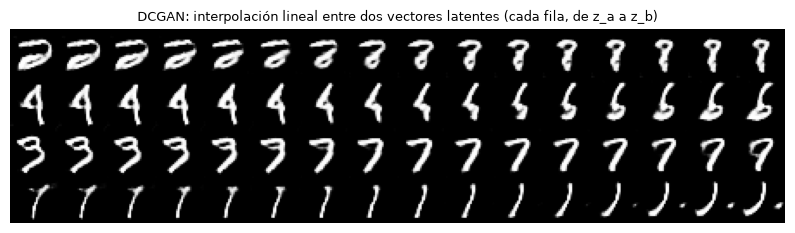

In [8]:
g = torch.Generator(device=device).manual_seed(7)
extremos = torch.randn(4, 2, LATENTE, generator=g, device=device)        # 4 pares (z_a, z_b)
t = torch.linspace(0, 1, 16, device=device).view(1, 16, 1)
caminos = (1 - t) * extremos[:, :1] + t * extremos[:, 1:]                 # (4, 16, LATENTE)
G_conv.eval()
with torch.no_grad():
    imagenes = G_conv(caminos.reshape(-1, LATENTE))
mostrar(imagenes, "DCGAN: interpolación lineal entre dos vectores latentes (cada fila, de z_a a z_b)", filas=4)
plt.show()

Las transiciones son suaves: un 2 se transforma poco a poco en un 9, un 4 en un 6 y un 3 en un 7, pasando por formas intermedias plausibles en lugar de saltar de golpe o atravesar ruido; en la última fila, un 1 se curva hasta una forma que ya no es un dígito claro. El generador ha aprendido un espacio latente continuo, en el que moverse equivale a variar la forma y el grosor del trazo.

## 4. Parámetros importantes y errores comunes

### 4.1. Parámetros que conviene conocer

| Parámetro | Qué controla | Consejo |
|---|---|---|
| Dimensión latente $k$ | Variedad que puede codificar el generador | 64–128 en imágenes pequeñas; más no mejora y solo añade dimensiones que el generador ignora |
| Tasa de aprendizaje y $\beta_1$ de Adam | Estabilidad del juego | $2\cdot10^{-4}$ y $\beta_1=0{,}5$ (receta DCGAN) |
| Pasos de $D$ por paso de $G$ | Equilibrio entre las dos redes | 1:1 con BCE; 5:1 en WGAN |
| Activaciones | Flujo del gradiente | LeakyReLU (pendiente 0,2) en $D$; ReLU en $G$ y `tanh` a la salida |
| Normalización por lotes | Estabilidad | En $G$ (no en su salida). En $D$, con cuidado: cada lote es solo de reales o solo de generadas y $D$ puede apoyarse en las estadísticas del lote; muchas implementaciones la quitan de $D$ o usan normalización espectral |
| *Dropout* o ruido en $D$ | Evitar que $D$ gane con demasiada ventaja | 0,3 en las capas densas de $D$ |
| Rango de los datos | Coherencia con la salida de $G$ | $[-1,1]$ si $G$ acaba en `tanh` |
| Épocas | Calidad | Decídelas por la calidad de las muestras (visual, Fréchet), no por las pérdidas |

### 4.2. Errores comunes

- **Poner una sigmoide en $D$ y usar a la vez `BCEWithLogitsLoss`.** Esa pérdida ya aplica la sigmoide: con dos, la salida de $D$ queda atrapada en $(0{,}5;\,0{,}73)$, $D$ satura y el generador deja de recibir gradiente (demo siguiente). O sigmoide + `BCELoss`, o logit + `BCEWithLogitsLoss` (mejor, más estable).
- **Colocar `.detach()` en el sitio equivocado.** En el paso de $D$ se desconecta la **imagen generada**, `D(falsas.detach())`, no la salida: `D(falsas).detach()` corta el gradiente hacia el propio $D$, que entonces no aprende nada de las falsificaciones. En el paso de $G$ no debe haber `detach`.
- **Diagnosticar mal un entrenamiento muerto.** Si las dos pérdidas se quedan **exactamente constantes** desde la segunda época, no es colapso de modos: el entrenamiento está parado (sin gradiente). El colapso de modos se ve en las muestras (poca variedad) y con un clasificador (3.5), no en unas pérdidas planas.
- **Leer las pérdidas como medida de calidad.** Una pérdida del generador baja no significa buenas imágenes, ni una alta malas: en las primeras épocas de 3.3 la pérdida de $G$ sube mientras las muestras mejoran. Usa un $\mathbf{z}$ fijo para inspeccionar y una métrica como la distancia de Fréchet.
- **Datos y generador en rangos distintos.** Si $G$ acaba en `tanh` ($[-1,1]$) y las imágenes reales están en $[0,1]$, $D$ las distingue por el rango (las reales nunca tienen valores negativos) y el generador no puede ganar.
- **Olvidar `G.eval()` al generar con normalización por lotes**, o generar lotes de tamaño 1 en modo entrenamiento: la normalización usaría las estadísticas de ese lote.
- **Dimensión latente desproporcionada.** Un $\mathbf{z}$ de 500 dimensiones para dígitos de $28\times28$ no aporta: la mayoría de las direcciones del espacio latente no se usan.

#### Demo: doble sigmoide y `detach` mal colocado

Reproducimos los dos fallos a la vez en la GAN densa (sigmoide al final de $D$ con `BCEWithLogitsLoss` y `D(falsas).detach()` en el paso de $D$) durante 2 épocas, y medimos la norma del gradiente que recibe el generador.

In [9]:
torch.manual_seed(0)
G_mal = generador_denso().to(device)
D_mal = nn.Sequential(*discriminador_denso(), nn.Sigmoid()).to(device)        # sigmoide de más
opt_G = torch.optim.Adam(G_mal.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D_mal.parameters(), lr=2e-4, betas=(0.5, 0.999))
bce = nn.BCEWithLogitsLoss()                                                  # que vuelve a aplicar la sigmoide
for epoca in range(1, 3):
    suma, norma_grad, lotes = np.zeros(2), 0.0, torch.randperm(len(X), device=device).split(128)
    for i in lotes:
        unos, ceros = torch.ones(len(i), 1, device=device), torch.zeros(len(i), 1, device=device)
        falsas = G_mal(torch.randn(len(i), LATENTE, device=device))
        perdida_D = bce(D_mal(X[i]), unos) + bce(D_mal(falsas).detach(), ceros)    # detach mal colocado
        opt_D.zero_grad(); perdida_D.backward(); opt_D.step()
        perdida_G = bce(D_mal(falsas), unos)
        opt_G.zero_grad(); perdida_G.backward()
        norma_grad += torch.cat([p.grad.flatten() for p in G_mal.parameters()]).norm().item()
        opt_G.step()
        suma += [perdida_D.item(), perdida_G.item()]
    print(f"Época {epoca}: pérdida D = {suma[0] / len(lotes):.4f} | pérdida G = {suma[1] / len(lotes):.4f} | "
          f"norma media del gradiente de G = {norma_grad / len(lotes):.1e}")
print(f"log(1 + e^-1) = {np.log1p(np.exp(-1)):.4f} | log(1 + e^-1) + log(1 + e) = {np.log1p(np.exp(-1)) + np.log1p(np.exp(1)):.4f}")
print(f"Gradiente medio de G en la GAN correcta, primer lote: ", end="")
G_ok, D_ok = generador_denso().to(device), discriminador_denso().to(device)
bce(D_ok(G_ok(torch.randn(128, LATENTE, device=device))), torch.ones(128, 1, device=device)).backward()
print(f"{torch.cat([p.grad.flatten() for p in G_ok.parameters()]).norm().item():.1e}")

Época 1: pérdida D = 1.6213 | pérdida G = 0.3161 | norma media del gradiente de G = 1.7e-03


Época 2: pérdida D = 1.6265 | pérdida G = 0.3133 | norma media del gradiente de G = 2.3e-06
log(1 + e^-1) = 0.3133 | log(1 + e^-1) + log(1 + e) = 1.6265
Gradiente medio de G en la GAN correcta, primer lote: 1.0e-01


En la primera época el discriminador aprende a dar la máxima salida posible a todo. Con la sigmoide de más esa salida es 1, y `BCEWithLogitsLoss` la trata como un logit: la pérdida del generador es $\log(1+e^{-1})=0{,}3133$ y la del discriminador $0{,}3133+\log(1+e)=1{,}6265$, **exactamente** los valores de la segunda época. A partir de ahí nada cambia: el gradiente que recibe el generador es del orden de $10^{-6}$, unas 40 000 veces menor que en el primer lote de una GAN correcta ($10^{-1}$), porque la sigmoide interna está saturada. El `detach` mal colocado completa el problema: $D$ nunca recibe la señal de las imágenes generadas, así que solo aprende a decir "real". Unas pérdidas idénticas época tras época no indican colapso de modos, sino un entrenamiento parado.

## 5. Comparación con métodos relacionados

| Modelo | Calidad de las muestras | Diversidad | Velocidad al generar | Estabilidad del entrenamiento | Da la probabilidad de los datos | Cuándo usarlo |
|---|---|---|---|---|---|---|
| **[Autoencoder variacional (VAE)](05-autoencoders.ipynb)** | Media (borrosas) | Alta | Muy rápida (una pasada) | Alta | Una cota inferior | Espacio latente útil, generación rápida sin gran detalle |
| **GAN** | Alta (nítidas) | Riesgo de colapso de modos | Muy rápida (una pasada) | Baja | No | Generación en tiempo real, superresolución, traducción entre imágenes |
| **[Modelos de difusión](09-modelos-de-difusion.ipynb)** | Muy alta | Alta | Lenta (cientos de pasos) | Alta | Una cota inferior | Estado del arte en imagen, audio y vídeo |
| **Autorregresivos** ([transformers](07-atencion-y-transformers.ipynb)) | Alta | Alta | Lenta (un elemento cada vez) | Alta | Sí, exacta | Texto; imagen y audio como secuencias de tokens |

## 6. Referencias

### Fuentes

- LeCun, Y., Bottou, L., Bengio, Y. y Haffner, P. (1998). «Gradient-based learning applied to document recognition». *Proceedings of the IEEE*, 86(11), 2278–2324. Origen de MNIST, descargado con [`torchvision.datasets.MNIST`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html).
- PyTorch: [*DCGAN tutorial*](https://pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html), [`BCEWithLogitsLoss`](https://pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html), [`nn.ConvTranspose2d`](https://pytorch.org/docs/stable/generated/torch.nn.ConvTranspose2d.html) y [`Tensor.detach`](https://pytorch.org/docs/stable/generated/torch.Tensor.detach.html). SciPy: [`scipy.linalg.sqrtm`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.sqrtm.html).

### Para saber más

- Goodfellow, I., Pouget-Abadie, J., Mirza, M., Xu, B., Warde-Farley, D., Ozair, S., Courville, A. y Bengio, Y. (2014). [«Generative adversarial nets»](https://arxiv.org/abs/1406.2661). *Advances in Neural Information Processing Systems* 27 (NeurIPS 2014), 2672–2680. El artículo que presentó las GAN y el análisis del juego minimax.
- Radford, A., Metz, L. y Chintala, S. (2016). [«Unsupervised representation learning with deep convolutional generative adversarial networks»](https://arxiv.org/abs/1511.06434). *International Conference on Learning Representations (ICLR)*. La DCGAN y sus recomendaciones de arquitectura, que siguen siendo el punto de partida.